In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os
from patchify import patchify  #Only to handle large images
import random
from scipy import ndimage
import glob
import cv2
from tqdm import tqdm
import torch
import scipy

In [2]:
#Used to quickly display an image
def imshow(img, title, cmap = 'gray', axis = 'off', figsize = (10, 10)):
    plt.figure(figsize= figsize)
    plt.imshow(img, cmap = cmap)
    plt.title(title)
    plt.axis(axis)
    plt.show()  

In [3]:
#Storing all file paths of images in a list of strings
import os
directory = r"C:\Users\adamain\Downloads\ProcessedSpiderWebs"
image_paths = []
for filename in os.listdir(directory):
    if filename.lower().endswith(".png"):
        image_paths.append(os.path.join(directory, filename))
print(image_paths)

['C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 4_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26

In [4]:
all_images = []
for path in image_paths:
    all_images.append(cv2.imread(path))
    cv2.cvtColor(all_images[len(all_images)-1], cv2.COLOR_BGR2RGB)

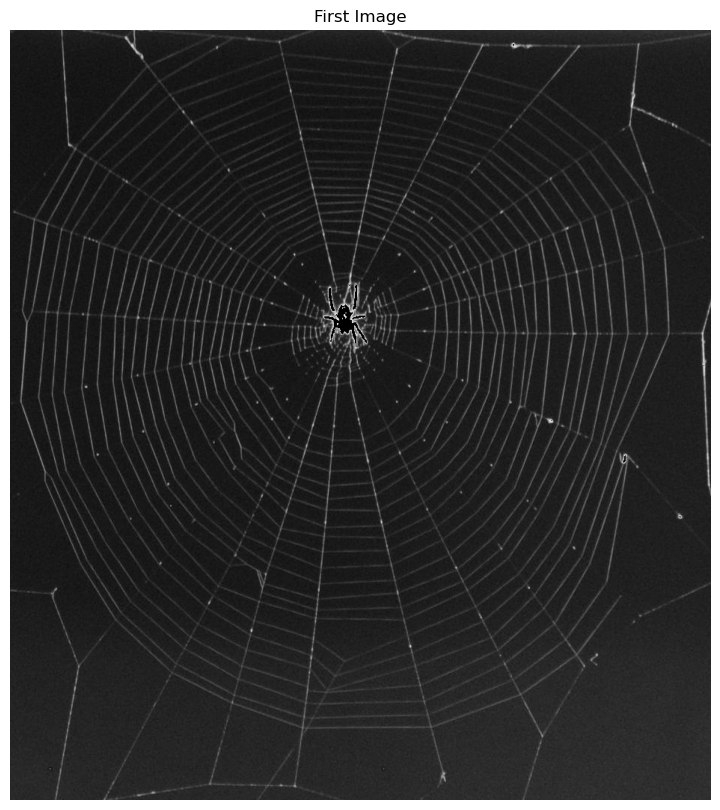

In [5]:
imshow(all_images[0], title = "First Image")

In [6]:
import cv2
import numpy as np

def apply_multi_gabor(gray, orientations=8, ksize=21):
    """
    Apply multiple Gabor filters to enhance line structures in various directions.
    """
    filtered_imgs = []
    for theta in np.linspace(0, np.pi, orientations, endpoint=False):
        kernel = cv2.getGaborKernel((ksize, ksize), sigma=4.0, theta=theta,
                                    lambd=10.0, gamma=0.5, psi=0, ktype=cv2.CV_32F)
        filtered = cv2.filter2D(gray, cv2.CV_8UC1, kernel)
        filtered_imgs.append(filtered)
    return np.max(filtered_imgs, axis=0)

def enhance_spider_web_smart2(gray_image):
    """
    Smarter enhancement: Tophat + multi-orientation Gabor filters + CLAHE.
    Designed to target spider web geometries more robustly.
    """
    gray = gray_image.copy()

    # Step 1: Morphological tophat
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,5))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)

    # Step 2: Gabor filters for radial/circular lines
    gabor_enhanced = apply_multi_gabor(tophat, orientations=12, ksize=25)
    # Step 3: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    final = clahe.apply(gabor_enhanced)

    return final


In [7]:
def preprocess_web(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    results = enhance_spider_web_smart2(gray)
    _, edited = cv2.threshold(results, 220, 255, cv2.THRESH_BINARY) 
    imshow(edited, title = "Results")
    return edited

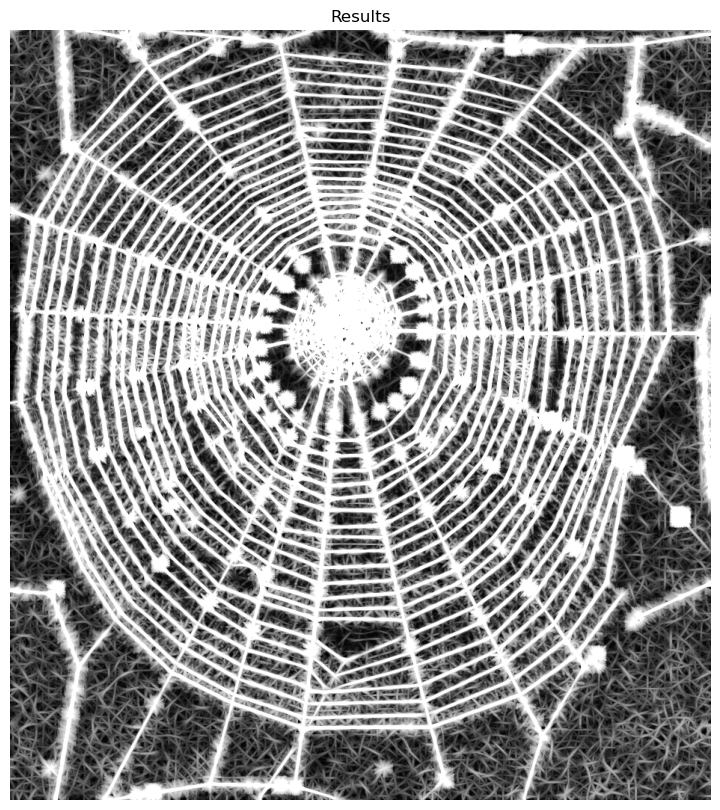

In [8]:
gray = cv2.cvtColor(all_images[0], cv2.COLOR_BGR2GRAY)
results = enhance_spider_web_smart2(gray)
imshow(results, "Results")

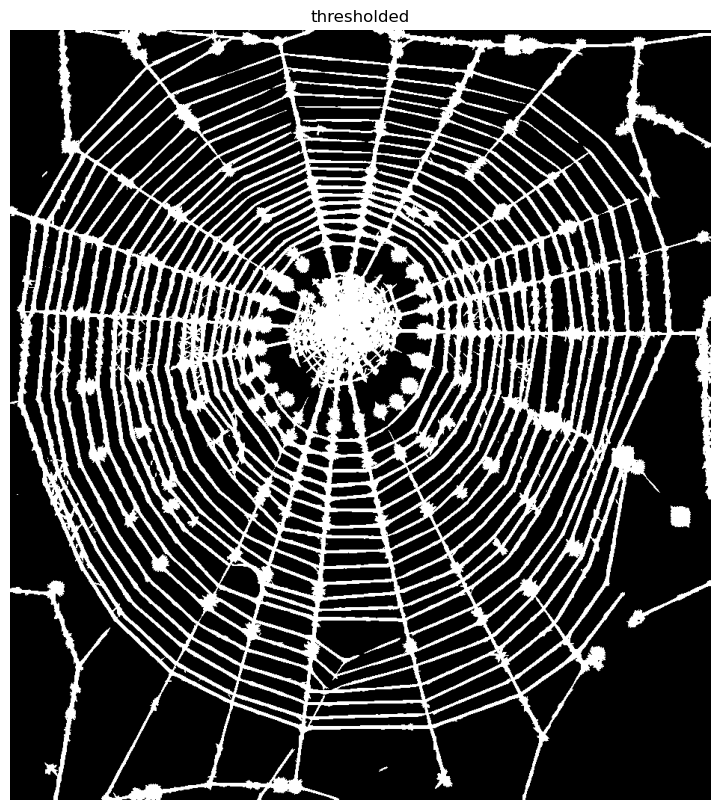

In [9]:
_, edited = cv2.threshold(results, 220, 255, cv2.THRESH_BINARY) 
imshow(edited, title = "thresholded")
#Try using the bright circles to your advantage. We know that they are they because web passes through them, so reconstruct radials passing through bright circles.Then calculate an average radius for the radials and get angle between them (might be easier)

In [10]:
import torch
from segment_anything import sam_model_registry, SamPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Point to SAM1 checkpoint, e.g. sam_vit_h_4b8939.pth
checkpoint_path = r"C:\Users\adamain\Downloads\sam_vit_h_4b8939.pth"

# Use correct key based on model variant: vit_h, vit_l, or vit_b
model_type = "vit_h"
model = sam_model_registry[model_type](checkpoint=checkpoint_path)
model.to(device)
model.eval()

predictor = SamPredictor(model)



Circle: center=(446, 398), capped radius=80, score=0.960


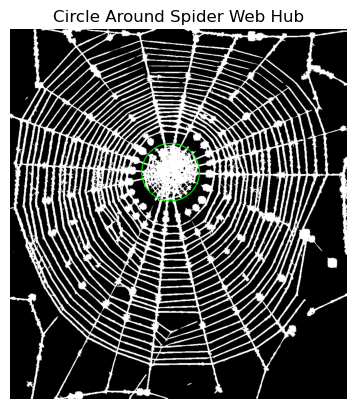

In [11]:
import numpy as np
import cv2
from sklearn.linear_model import RANSACRegressor
import matplotlib.pyplot as plt

# --- Inputs ---
positive_points = [(450, 350), (450, 400)]  # Points inside the hub
negative_points = [(100, 100), (500, 100)]  # Points outside the hub
image = edited

input_points = np.array(positive_points + negative_points)
input_labels = np.array([1]*len(positive_points) + [0]*len(negative_points))

# Ensure image is 3-channel RGB for SAM
if len(image.shape) == 2:
    image = np.stack([image]*3, axis=-1)
elif image.shape[2] == 1:
    image = np.repeat(image, 3, axis=2)

predictor.set_image(image)

masks, scores, _ = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

def fit_circle(mask):
    ys, xs = np.where(mask)
    if len(xs) < 5:
        return None
    x = xs[:, np.newaxis]
    y = ys[:, np.newaxis]
    A = np.hstack([2 * x, 2 * y, np.ones_like(x)])
    b = x**2 + y**2
    model = RANSACRegressor()
    model.fit(A, b)
    c = model.estimator_.coef_
    d = model.estimator_.intercept_
    centerx = int(c[0][0])
    centery = int(c[0][1])
    r = int(np.sqrt(d + c[0][0]**2 + c[0][1]**2)[0])
    return (centerx, centery, r)

best_idx = np.argmax(scores)
best_mask = masks[best_idx]
best_score = scores[best_idx]
fallback_circle = fit_circle(best_mask)
centerx, centery, r = fallback_circle
r = 80
print(f"Circle: center=({centerx}, {centery}), capped radius={r}, score={best_score:.3f}")

output_image = image.copy()
if centerx is not None and centery is not None and r is not None:
    cv2.circle(output_image, (centerx, centery), r, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title("Circle Around Spider Web Hub")
plt.axis("off")
plt.show()


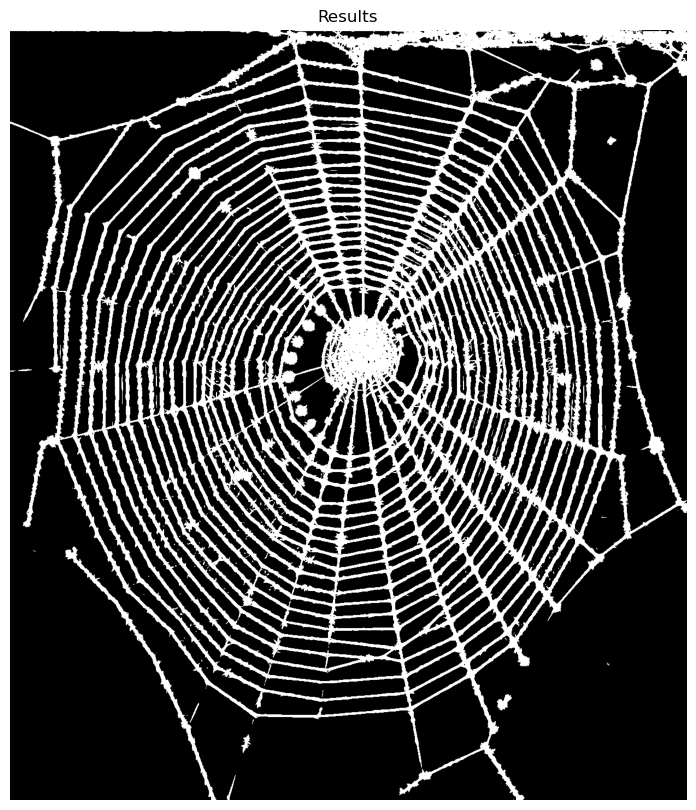

In [12]:
#Preprocess test image
test_im = preprocess_web(all_images[2])

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from scipy.ndimage import gaussian_filter, label, center_of_mass

def refined_spider_web_center(binary_img, box_width=225, box_height=225, visualize=False):
    """
    Estimate the center of a spider web using skeleton tracing and vote accumulation.
    
    Args:
        binary_img (np.ndarray): Binarized grayscale image
        box_width (int): Width of the bounding box
        box_height (int): Height of the bounding box
        visualize (bool): Show diagnostic plots
    
    Returns:
        tuple: (center_x, center_y, cropped_image, original_with_box, (x1, y1, x2, y2))
    """
    if binary_img is None:
        raise ValueError("Input image is None")
    if len(binary_img.shape) == 3:
        binary_img = cv2.cvtColor(binary_img, cv2.COLOR_BGR2GRAY)

    binary = (binary_img > 127).astype(np.uint8)

    # Step 1: Skeletonize
    skeleton = skeletonize(binary > 0).astype(np.uint8)

    # Step 2: For each skeleton pixel, draw a short line inward (opposite of local direction)
    h, w = skeleton.shape
    vote_map = np.zeros((h, w), dtype=np.float32)

    kernel_size = 3
    offset = 30

    ys, xs = np.where(skeleton)
    for y, x in zip(ys, xs):
        window = skeleton[max(0, y - kernel_size):min(h, y + kernel_size + 1),
                          max(0, x - kernel_size):min(w, x + kernel_size + 1)]
        wy, wx = np.where(window)
        wy = wy + y - (y - kernel_size if y - kernel_size >= 0 else 0)
        wx = wx + x - (x - kernel_size if x - kernel_size >= 0 else 0)

        vectors = np.stack([wx - x, wy - y], axis=1)
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-8
        directions = vectors / norms

        mean_dir = -np.mean(directions, axis=0)
        mean_dir /= (np.linalg.norm(mean_dir) + 1e-8)

        cx = int(round(x + mean_dir[0] * offset))
        cy = int(round(y + mean_dir[1] * offset))

        if 0 <= cx < w and 0 <= cy < h:
            vote_map[cy, cx] += 1

    # Step 3: Smooth vote map and find center of most dense region
    vote_map_blur = gaussian_filter(vote_map, sigma=5)
    threshold = vote_map_blur.max() * 0.5
    blobs, _ = label(vote_map_blur > threshold)

    if blobs.max() == 0:
        cy, cx = np.unravel_index(np.argmax(vote_map_blur), vote_map_blur.shape)
    else:
        cy, cx = center_of_mass(vote_map_blur, blobs, np.argmax(np.bincount(blobs.flat)[1:]) + 1)
        cx, cy = int(cx), int(cy)

    # Step 4: Bounding box
    x1 = max(0, cx - box_width // 2)
    y1 = max(0, cy - box_height // 2)
    x2 = min(w, cx + box_width // 2)
    y2 = min(h, cy + box_height // 2)

    if x2 - x1 < box_width:
        if x1 == 0:
            x2 = min(w, x1 + box_width)
        else:
            x1 = max(0, x2 - box_width)
    if y2 - y1 < box_height:
        if y1 == 0:
            y2 = min(h, y1 + box_height)
        else:
            y1 = max(0, y2 - box_height)

    cropped = binary_img[y1:y2, x1:x2]
    img_with_box = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(img_with_box, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.circle(img_with_box, (cx, cy), 5, (0, 0, 255), -1)

    if visualize:
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img_with_box, cmap='gray')
        plt.title("Center and Bounding Box")
        plt.subplot(1, 2, 2)
        plt.imshow(vote_map_blur, cmap='hot')
        plt.scatter(cx, cy, c='cyan')
        plt.title("Vote Accumulation (Smoothed)")
        plt.tight_layout()
        plt.show()

    return cx, cy, cropped, img_with_box, (x1, y1, x2, y2)


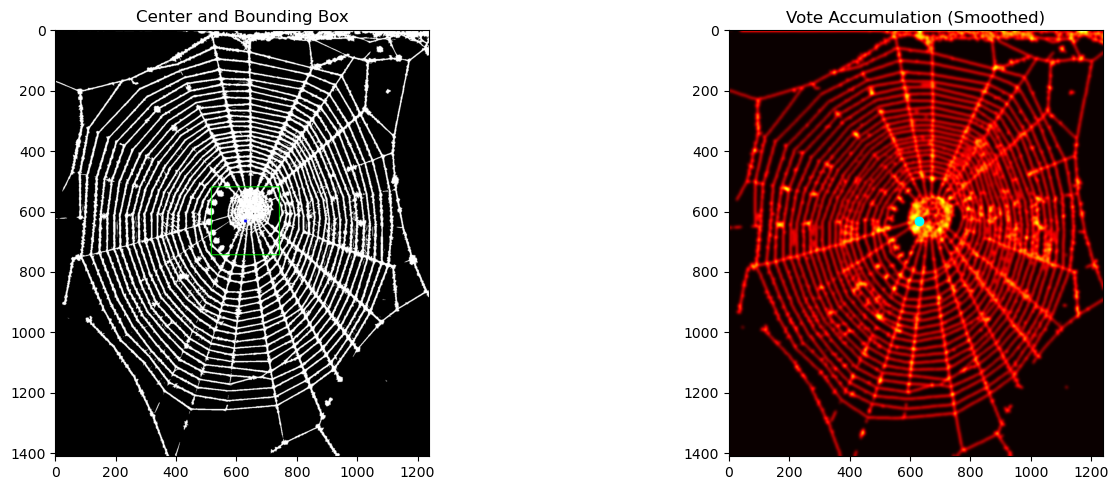

In [14]:
cx, cy, cropped, vis_img, box = refined_spider_web_center(test_im, visualize=True)

In [15]:
import numpy as np
import cv2
from segment_anything import SamPredictor
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

def fit_circle(mask):
    ys, xs = np.where(mask)
    if len(xs) < 5:
        return None
    x = xs[:, np.newaxis]
    y = ys[:, np.newaxis]
    A = np.hstack([2 * x, 2 * y, np.ones_like(x)])
    b = x**2 + y**2
    model = RANSACRegressor()
    model.fit(A, b)
    c = model.estimator_.coef_
    d = model.estimator_.intercept_
    cx = int(c[0][0])
    cy = int(c[0][1])
    r = int(np.sqrt(d + c[0][0]**2 + c[0][1]**2)[0])
    return (cx, cy, r)

def find_black_pixel_far_from_white(image, white_thresh=200):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    white_mask = gray > white_thresh
    dist = distance_transform_edt(~white_mask)
    yx = np.unravel_index(np.argmax(dist), dist.shape)
    return (yx[1], yx[0])  # (x, y)

def find_second_negative_point(image, center, min_distance=150):
    """
    Find a pixel at least `min_distance` from the given center.
    Can be any pixel (not restricted to dark ones).
    """
    h, w = image.shape[:2]
    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    dist = np.sqrt((xx - center[0])**2 + (yy - center[1])**2)

    valid_mask = dist >= min_distance
    if np.any(valid_mask):
        farthest_idx = np.unravel_index(np.argmax(dist * valid_mask), dist.shape)
        return (farthest_idx[1], farthest_idx[0])  # (x, y)
    else:
        return (0, 0)

def find_hub_center_from_points(cropped_image, original_image, center_estimate, crop_box, predictor: SamPredictor, visualize=True):
    # Ensure image is RGB
    if cropped_image.ndim == 2:
        cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_GRAY2RGB)
    elif cropped_image.shape[2] == 4:
        cropped_image = cropped_image[:, :, :3]

    # Step 1: Set image in predictor
    predictor.set_image(cropped_image)

    # Step 2: Initial positive point
    center_local_x = int(center_estimate[0] - crop_box[0])
    center_local_y = int(center_estimate[1] - crop_box[1])
    pos1 = np.array([[center_local_x, center_local_y]])

    # Step 3: First negative point — far from white
    neg1 = find_black_pixel_far_from_white(cropped_image)

    # --- First SAM prompt ---
    point_coords_1 = np.concatenate([pos1, [neg1]], axis=0)
    point_labels_1 = np.array([1, 0])
    masks_1, _, _ = predictor.predict(
        point_coords=point_coords_1,
        point_labels=point_labels_1,
        multimask_output=False
    )

    mask_1 = masks_1[0]
    first_circle = fit_circle(mask_1)
    if first_circle is None:
        center_crop = pos1[0]
    else:
        cx1, cy1, _ = first_circle
        center_crop = (cx1, cy1)

    # Step 4: Second prompt — new positive + new negative (≥150px away)
    pos2 = np.array([[center_crop[0], center_crop[1]]])
    neg2 = find_second_negative_point(cropped_image, center_crop, min_distance=150)

    point_coords_2 = np.concatenate([pos1, pos2, [neg1], [neg2]], axis=0)
    point_labels_2 = np.array([1, 1, 0, 0])
    masks_2, _, _ = predictor.predict(
        point_coords=point_coords_2,
        point_labels=point_labels_2,
        multimask_output=False
    )

    mask_2 = masks_2[0]
    final_circle = fit_circle(mask_2)
    if final_circle is None:
        center_crop_final = pos2[0]
        radius = None
    else:
        cx2, cy2, radius = final_circle
        center_crop_final = (cx2, cy2)

    # Step 5: Convert to original image coordinates
    x_offset, y_offset = crop_box[:2]
    center_original = (int(center_crop_final[0] + x_offset), int(center_crop_final[1] + y_offset))

    # Step 6: Visualization
    if visualize:
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))

        # Cropped with final mask
        ax[0].imshow(cropped_image)
        ax[0].imshow(mask_2, alpha=0.4, cmap='Reds')
        ax[0].scatter(*pos1[0], c='lime', label='Initial Positive')
        ax[0].scatter(*neg1, c='red', label='Negative 1 (far from white)')
        ax[0].scatter(*neg2, c='orange', label='Negative 2 (≥150px from center)')
        ax[0].scatter(*pos2[0], c='blue', label='Refined Positive')
        ax[0].scatter(*center_crop_final, c='cyan', label='Final Center')
        if radius:
            circ = plt.Circle(center_crop_final, radius, color='blue', fill=False, lw=2)
            ax[0].add_patch(circ)
        ax[0].set_title("Cropped Image + Final Circle Fit")
        ax[0].legend()

        # Original image with projected center
        circle_image = cv2.cvtColor(original_image.copy(), cv2.COLOR_GRAY2RGB)
        r = 80
        cv2.circle(circle_image, center_original, r, (0, 255, 0), 2)
        ax[1].imshow(circle_image)
        ax[1].scatter(*center_original, c='red', s=30, label='Projected Center')
        ax[1].set_title("Original Image with Projected Center")
        ax[1].legend()

        plt.show()

    return center_original, circle_image


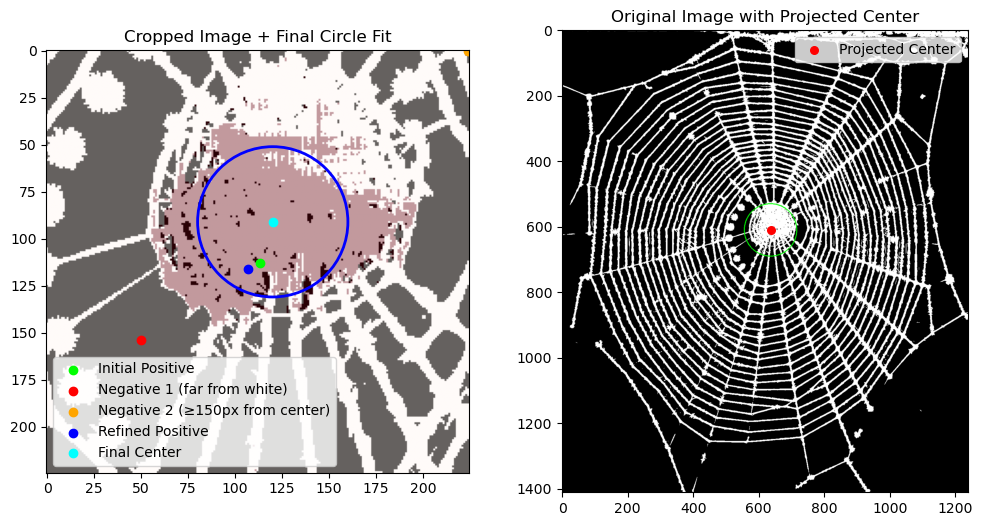

In [25]:
center2, circle2 = find_hub_center_from_points(cropped, test_im, (cx, cy), box, predictor = predictor, visualize=True)

In [17]:
import numpy as np
import cv2

def refine_center_by_max_white(binary_image, initial_center, search_radius=10, circle_radius=80, step=1, visualize=False):
    """
    Refines a given center by searching nearby positions to maximize the number of white pixels inside a circle.

    Args:
        binary_image (np.ndarray): Binarized (0 or 255) grayscale image.
        initial_center (tuple): (x, y) coordinates of the initial center.
        search_radius (int): Max pixel distance to shift the center.
        circle_radius (int): Radius of the circle to evaluate.
        step (int): Step size for searching around the initial center.
        visualize (bool): Whether to show the best circle on the image.

    Returns:
        tuple: (best_x, best_y) new center with highest white pixel count.
    """
    h, w = binary_image.shape
    best_center = initial_center
    max_white_count = -1

    x0, y0 = initial_center

    for dx in range(-search_radius, search_radius + 1, step):
        for dy in range(-search_radius, search_radius + 1, step):
            x = x0 + dx
            y = y0 + dy
            if x < 0 or y < 0 or x >= w or y >= h:
                continue

            # Create a circular mask
            Y, X = np.ogrid[:h, :w]
            dist_sq = (X - x) ** 2 + (Y - y) ** 2
            circle_mask = dist_sq <= circle_radius ** 2

            white_count = np.sum(binary_image[circle_mask] > 127)

            if white_count > max_white_count:
                max_white_count = white_count
                best_center = (x, y)

    if visualize:
        display = cv2.cvtColor(binary_image, cv2.COLOR_GRAY2BGR)
        cv2.circle(display, best_center, circle_radius, (0, 255, 0), 2)
        cv2.circle(display, best_center, 4, (0, 0, 255), -1)
        plt.imshow(display)
        plt.title(f"Refined Center: {best_center} (White Pixels: {max_white_count})")
        plt.axis('off')
        plt.show()

    return best_center


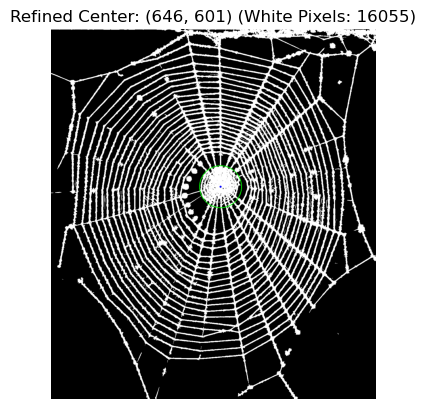

In [26]:
best_center = refine_center_by_max_white(test_im, center2, search_radius=20, circle_radius=80, step=1, visualize=True)

In [27]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

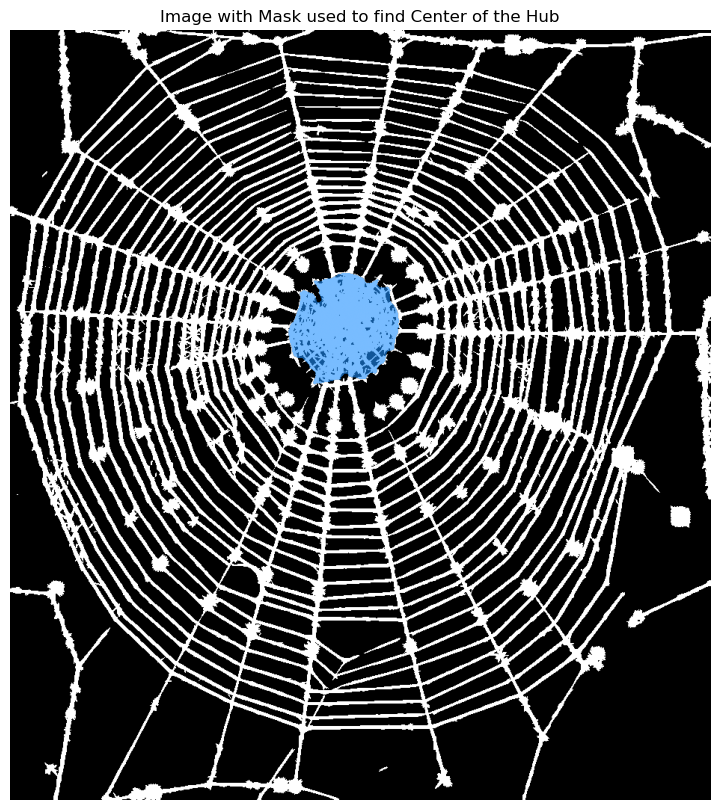

In [28]:
plt.figure(figsize=(10,10))
plt.imshow(edited, cmap = 'gray')
show_mask(best_mask, plt.gca())
plt.title("Image with Mask used to find Center of the Hub")
plt.axis('off')
plt.show()  

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List
import math
import scipy.signal


class SpiderWebAnalyzer:
    def __init__(self, image_path: str = None, image: np.ndarray = None):
        if image is not None:
            self.image = image
        elif image_path is not None:
            self.image = cv2.imread(image_path)
            if self.image is None:
                raise ValueError(f"Could not load image from {image_path}")
        else:
            raise ValueError("Either image_path or image must be provided")

        self.image_rgb = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
        self.image_gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        self.center = None
        self.radius = None

    def set_center_and_radius(self, center: Tuple[int, int], radius: int):
        self.center = center
        self.radius = radius

    def detect_center_interactive(self):
        def mouse_callback(event, x, y, flags, param):
            if event == cv2.EVENT_LBUTTONDOWN:
                self.center = (x, y)
                print(f"Center set to: ({x}, {y})")

        cv2.namedWindow('Click Center Point', cv2.WINDOW_NORMAL)
        cv2.setMouseCallback('Click Center Point', mouse_callback)

        temp_image = self.image.copy()
        cv2.imshow('Click Center Point', temp_image)

        print("Click on the center of the spider web hub, then press any key...")
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        if self.center is None:
            raise ValueError("No center point was selected")

    def create_radial_lines(self, line_length: int = None) -> List[Tuple[np.ndarray, np.ndarray]]:
        if self.center is None:
            raise ValueError("Center point must be set first")

        if line_length is None:
            line_length = self.radius if self.radius else min(self.image.shape[:2]) // 2

        lines = []
        center_x, center_y = self.center

        for angle_deg in range(360):
            angle_rad = math.radians(angle_deg)
            end_x = int(center_x + line_length * math.cos(angle_rad))
            end_y = int(center_y + line_length * math.sin(angle_rad))
            x_coords, y_coords = self._bresenham_line(center_x, center_y, end_x, end_y)
            lines.append((x_coords, y_coords))

        return lines

    def _bresenham_line(self, x0: int, y0: int, x1: int, y1: int) -> Tuple[np.ndarray, np.ndarray]:
        dx = abs(x1 - x0)
        dy = abs(y1 - y0)
        sx = 1 if x0 < x1 else -1
        sy = 1 if y0 < y1 else -1
        err = dx - dy

        x_coords, y_coords = [], []
        x, y = x0, y0

        while True:
            x_coords.append(x)
            y_coords.append(y)
            if x == x1 and y == y1:
                break
            e2 = 2 * err
            if e2 > -dy:
                err -= dy
                x += sx
            if e2 < dx:
                err += dx
                y += sy

        return np.array(x_coords), np.array(y_coords)

    def score_lines_by_white_pixels(self, lines: List[Tuple[np.ndarray, np.ndarray]], white_threshold: int = 240) -> List[int]:
        scores = []
        height, width = self.image_gray.shape

        for x_coords, y_coords in lines:
            valid_mask = (x_coords >= 0) & (x_coords < width) & (y_coords >= 0) & (y_coords < height)
            valid_x = x_coords[valid_mask]
            valid_y = y_coords[valid_mask]
            if len(valid_x) > 0:
                pixel_values = self.image_gray[valid_y, valid_x]
                white_count = np.sum(pixel_values >= white_threshold)
                scores.append(white_count)
            else:
                scores.append(0)

        return scores

    def find_peak_lines(self, scores: List[int], min_height: int = 50) -> List[int]:
        peaks, _ = scipy.signal.find_peaks(scores, height=min_height)
        return peaks.tolist()

    def filter_peaks_by_angle(self, peak_indices: List[int], scores: List[int], angle_thresh: int = 5) -> List[int]:
        if not peak_indices:
            return []

        sorted_peaks = sorted(peak_indices)
        filtered_peaks = []
        current_cluster = [sorted_peaks[0]]

        for i in range(1, len(sorted_peaks)):
            if sorted_peaks[i] - sorted_peaks[i - 1] <= angle_thresh:
                current_cluster.append(sorted_peaks[i])
            else:
                best_peak = max(current_cluster, key=lambda idx: scores[idx])
                filtered_peaks.append(best_peak)
                current_cluster = [sorted_peaks[i]]

        if current_cluster:
            best_peak = max(current_cluster, key=lambda idx: scores[idx])
            filtered_peaks.append(best_peak)

        return filtered_peaks

    def visualize_analysis(self, lines: List[Tuple[np.ndarray, np.ndarray]], scores: List[int],
                           show_all_lines: bool = False, show_top_n: int = 10,
                           highlight_peaks: bool = False, min_height: int = 50,
                           angle_filter_deg: int = 5):
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

        ax1.imshow(self.image_rgb)
        ax1.set_title('Original Image')
        ax1.axis('off')

        ax2.imshow(self.image_rgb)
        if self.center:
            ax2.plot(self.center[0], self.center[1], 'ro', markersize=8, label='Center')
        if self.radius and self.center:
            circle = plt.Circle(self.center, self.radius, fill=False, color='green', linewidth=2)
            ax2.add_patch(circle)
        ax2.set_title('Center and Analysis Circle')
        ax2.legend()
        ax2.axis('off')

        ax3.imshow(self.image_rgb)
        if self.center:
            ax3.plot(self.center[0], self.center[1], 'ro', markersize=8)

        if lines and scores:
            if highlight_peaks:
                peak_indices = self.find_peak_lines(scores, min_height=min_height)
                peak_indices = self.filter_peaks_by_angle(peak_indices, scores, angle_thresh=angle_filter_deg)
                for i in peak_indices:
                    x_coords, y_coords = lines[i]
                    ax3.plot(x_coords, y_coords, 'b-', linewidth=2, alpha=0.8)
            else:
                top_indices = np.argsort(scores)[-show_top_n:]
                for i in top_indices:
                    x_coords, y_coords = lines[i]
                    ax3.plot(x_coords, y_coords, 'r-', linewidth=1, alpha=0.7)

        if show_all_lines and lines:
            for x_coords, y_coords in lines:
                ax3.plot(x_coords, y_coords, 'gray', linewidth=0.5, alpha=0.3)

        ax3.set_title('Radial Lines Highlighted')
        ax3.axis('off')

        ax4.bar(range(len(scores)), scores, alpha=0.7)
        ax4.set_title('White Pixel Scores by Angle')
        ax4.set_xlabel('Angle (degrees)')
        ax4.set_ylabel('White Pixel Count')

        if highlight_peaks:
            peak_indices = self.find_peak_lines(scores, min_height=min_height)
            peak_indices = self.filter_peaks_by_angle(peak_indices, scores, angle_thresh=angle_filter_deg)
            for i in peak_indices:
                ax4.bar(i, scores[i], color='blue', alpha=0.9)
            ax4.axhline(min_height, color='red', linestyle='--', label='Min Brightness Threshold')
            ax4.legend()
        else:
            top_indices = np.argsort(scores)[-show_top_n:]
            for i in top_indices:
                ax4.bar(i, scores[i], color='red', alpha=0.8)

        plt.tight_layout()
        plt.show()

    def get_analysis_stats(self, scores: List[int]) -> dict:
        if not scores:
            return {}

        scores_array = np.array(scores)

        stats = {
            'total_lines': len(scores),
            'mean_score': np.mean(scores_array),
            'median_score': np.median(scores_array),
            'std_score': np.std(scores_array),
            'min_score': np.min(scores_array),
            'max_score': np.max(scores_array),
            'top_10_angles': np.argsort(scores_array)[-10:].tolist(),
            'top_10_scores': sorted(scores_array)[-10:]
        }

        return stats
    def draw_lines_on_image(self, lines: List[Tuple[np.ndarray, np.ndarray]], color=(0, 0, 255), thickness=1) -> np.ndarray:
        """
        Draws the given lines on a copy of the original image.

        Args:
            lines: List of (x_coords, y_coords) tuples
            color: BGR color of the lines
            thickness: Line thickness

        Returns:
            Image with lines drawn (as a NumPy array)
        """
        image_copy = self.image.copy()
        for x_coords, y_coords in lines:
            for i in range(1, len(x_coords)):
                pt1 = (int(x_coords[i - 1]), int(y_coords[i - 1]))
                pt2 = (int(x_coords[i]), int(y_coords[i]))
                cv2.line(image_copy, pt1, pt2, color, thickness)
        return image_copy
#More robust usage function running many trials
import matplotlib.pyplot as plt

import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List
import cv2
import math

def circular_mean_deg(angles_deg: List[float], weights: List[float]) -> float:
    """
    Compute weighted circular mean of angles in degrees.
    """
    angles_rad = np.deg2rad(angles_deg)
    sin_sum = np.sum(np.sin(angles_rad) * weights)
    cos_sum = np.sum(np.cos(angles_rad) * weights)
    mean_angle_rad = math.atan2(sin_sum, cos_sum)
    mean_angle_deg = np.rad2deg(mean_angle_rad) % 360
    return mean_angle_deg

def robust_spider_web_analysis(image: np.ndarray,
                               center: Tuple[int, int],
                               radii: List[int],
                               white_threshold: int = 240,
                               peak_min_height: int = 50,
                               angle_filter_deg: int = 5,
                               vote_threshold: float = 100,  # tune after weighting
                               show_debug: bool = True) -> Tuple[List[float], List[Tuple[np.ndarray, np.ndarray]], np.ndarray]:
    """
    Spider web radial line detection with weighted voting and refined clustering using weighted circular mean.

    Args:
        image: Input BGR image as a NumPy array
        center: (x, y) center of the web
        radii: List of radii to try
        white_threshold: Threshold for white pixel detection
        peak_min_height: Minimum white pixel score to consider a peak
        angle_filter_deg: Angular tolerance for clustering (± degrees)
        vote_threshold: Minimum sum of scores in angle bin to be accepted
        show_debug: Show plots if True

    Returns:
        final_angles: List of refined stable angles (float degrees)
        final_lines: List of line coordinates (x_coords, y_coords)
        output_image: Image with stable lines drawn
    """

    angle_bins = [[] for _ in range(360)]
    # Store best scoring line and score per bin: {bin_angle: (line, score, raw_angle)}
    angle_to_lines = {}

    for radius in radii:
        analyzer = SpiderWebAnalyzer(image=image)
        analyzer.set_center_and_radius(center, radius)
        lines = analyzer.create_radial_lines()
        scores = analyzer.score_lines_by_white_pixels(lines, white_threshold=white_threshold)
        raw_peaks = analyzer.find_peak_lines(scores, min_height=peak_min_height)
        filtered_peaks = analyzer.filter_peaks_by_angle(raw_peaks, scores, angle_thresh=angle_filter_deg)

        for angle in filtered_peaks:
            score_at_angle = scores[angle]
            for delta in range(-angle_filter_deg, angle_filter_deg + 1):
                bin_angle = (angle + delta) % 360
                angle_bins[bin_angle].append((angle, lines[angle], score_at_angle))
                # Store or update best scoring line per bin
                if (bin_angle not in angle_to_lines) or (score_at_angle > angle_to_lines[bin_angle][1]):
                    angle_to_lines[bin_angle] = (lines[angle], score_at_angle, angle)

    # Weighted vote sums per angle bin
    vote_counts = [sum(entry[2] for entry in bin) for bin in angle_bins]

    # Angles passing vote threshold
    raw_stable_angles = [i for i, count in enumerate(vote_counts) if count >= vote_threshold]

    used_angles = set()
    final_angles = []
    final_lines = []

    # Cluster raw stable angles with ±angle_filter_deg and compute weighted circular mean
    for angle in raw_stable_angles:
        if angle in used_angles:
            continue

        cluster = [(a % 360) for a in range(angle - angle_filter_deg, angle + angle_filter_deg + 1)]
        cluster = [a for a in cluster if a in raw_stable_angles]

        # Collect all cluster entries with their scores and raw detected angles
        cluster_entries = []
        for a in cluster:
            if a in angle_to_lines:
                line, score, raw_angle = angle_to_lines[a]
                cluster_entries.append((a, line, score, raw_angle))

        if not cluster_entries:
            continue

        # Weighted circular mean of raw detected angles, weights = scores
        angles_for_mean = [entry[3] for entry in cluster_entries]
        scores_for_mean = [entry[2] for entry in cluster_entries]
        refined_angle = circular_mean_deg(angles_for_mean, scores_for_mean)

        # Select line with highest score in cluster to draw
        best_entry = max(cluster_entries, key=lambda e: e[2])
        best_line = best_entry[1]

        final_angles.append(refined_angle)
        final_lines.append(best_line)
        used_angles.update(cluster)

    # Draw final lines on image
    final_analyzer = SpiderWebAnalyzer(image=image)
    output_image = final_analyzer.draw_lines_on_image(final_lines, color=(0, 0, 255), thickness=2)

    if show_debug:
        fig, axs = plt.subplots(1, 2, figsize=(16, 6))

        axs[0].imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        axs[0].set_title("Stable Radial Lines (Drawn on Image)")
        axs[0].axis("off")

        axs[1].bar(range(360), vote_counts, color='gray')
        axs[1].set_title("Angle Vote Histogram (Weighted Sum of Scores, ±{}° tolerance)".format(angle_filter_deg))
        axs[1].set_xlabel("Angle (degrees)")
        axs[1].set_ylabel("Weighted Vote Sum")

        for angle in final_angles:
            axs[1].bar(int(round(angle)) % 360, vote_counts[int(round(angle)) % 360], color='green')

        plt.tight_layout()
        plt.show()

    return final_angles, final_lines, output_image





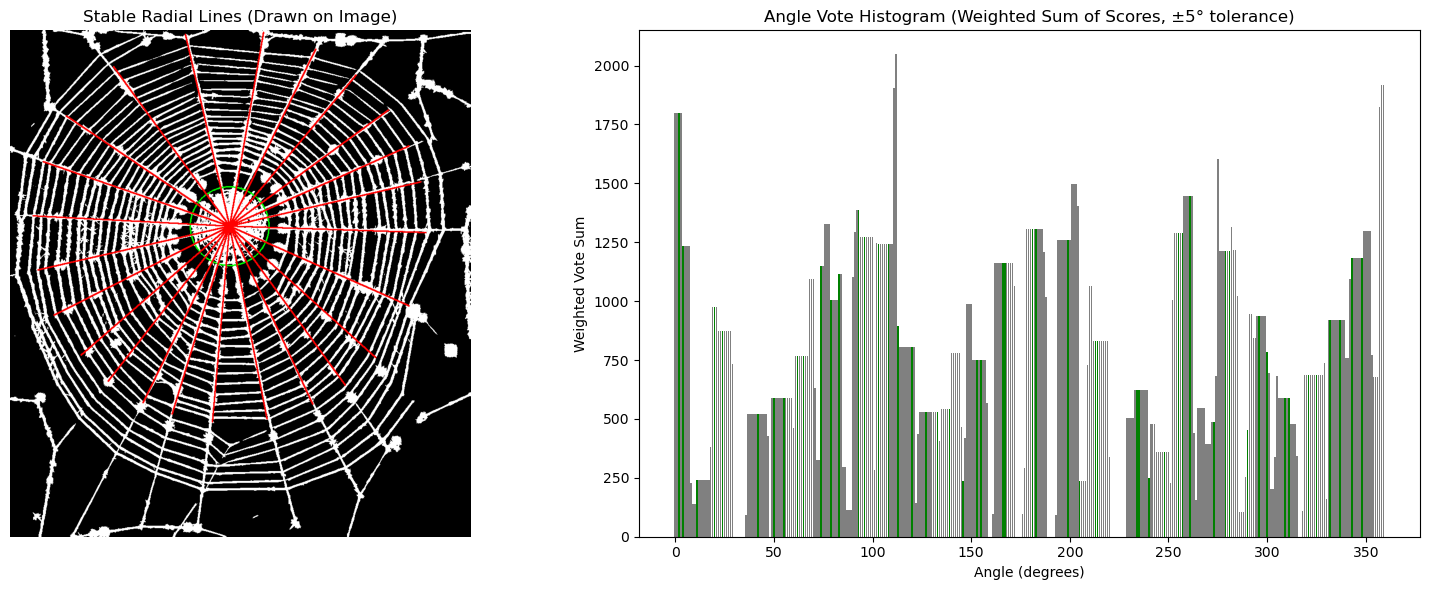

In [30]:
radii = [100, 200, 300, 350, 400]
angles, lines, line_img = robust_spider_web_analysis(
    image = output_image,
    radii = radii,
    center=(centerx, centery),
    peak_min_height=90
)

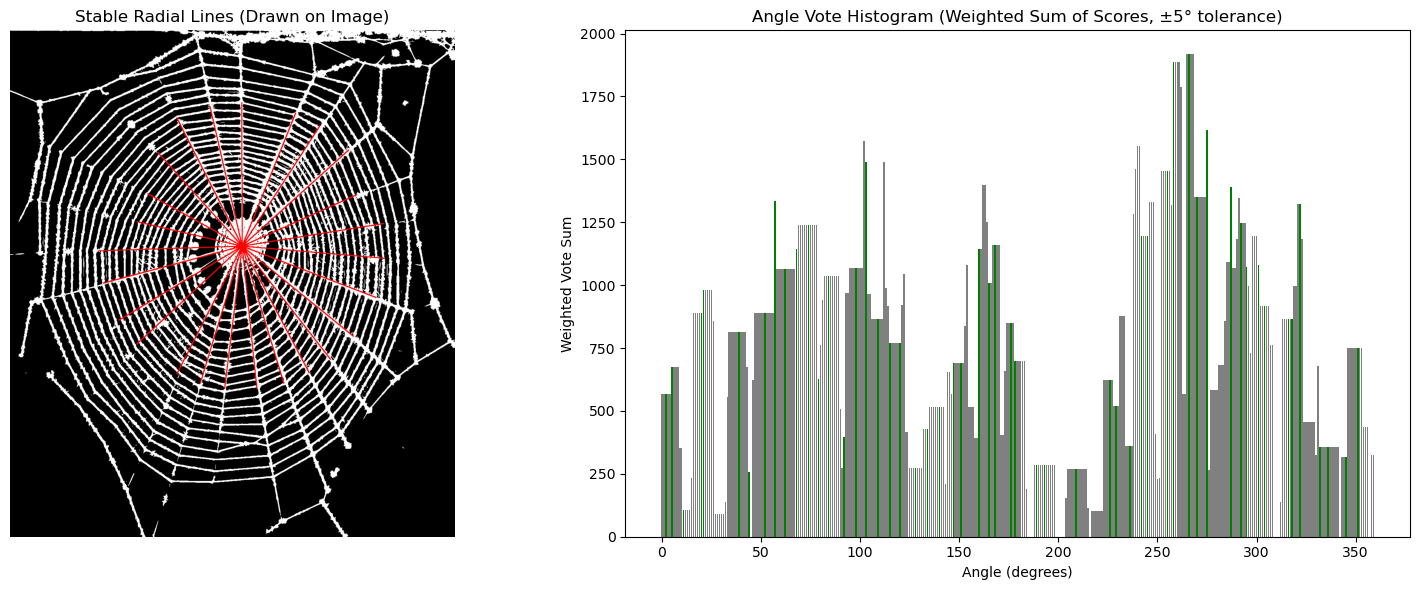

In [31]:
radii = [100, 200, 300, 350, 400]
angles2, lines2, line_img2 = robust_spider_web_analysis(
    image = cv2.cvtColor(test_im, cv2.COLOR_GRAY2RGB),
    radii = radii,
    center=best_center,
    peak_min_height=90,
)

In [21]:
import os
output_dir = r"C:\Users\adamain\Documents\Annotated Spiders"
base_name = os.path.basename(image_paths[0])
name_without_ext = os.path.splitext(base_name)[0]
annotated_path = os.path.join(output_dir, f"{name_without_ext}_annotated.png")
cv2.imwrite(annotated_path, line_img)

True